In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import chi2

from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

import scipy.stats as stats
import scikit_posthocs as sp


In [36]:
data = pd.read_csv("dataset.csv")
data = data.drop_duplicates().reset_index(drop=True)

data["ca"] = data["ca"].replace(4, 3)
data["thal"] = data["thal"].replace(0, 1)

target_col = "target"


In [37]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

X = data.drop(columns=[target_col])
y = data[target_col]


In [38]:
num_imp = SimpleImputer(strategy="median")
cat_imp = SimpleImputer(strategy="most_frequent")

X[numeric_features] = num_imp.fit_transform(X[numeric_features])
X[categorical_features] = cat_imp.fit_transform(X[categorical_features])

scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])


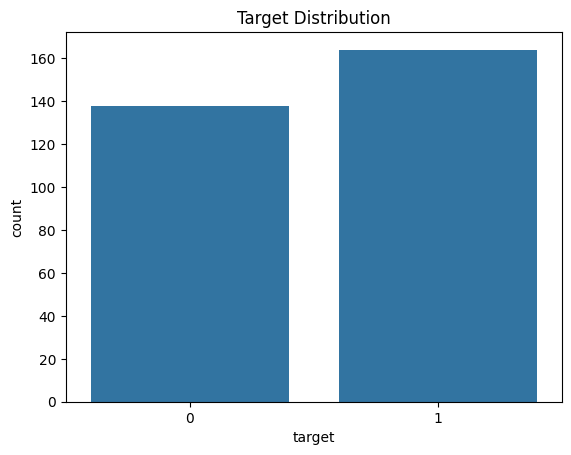

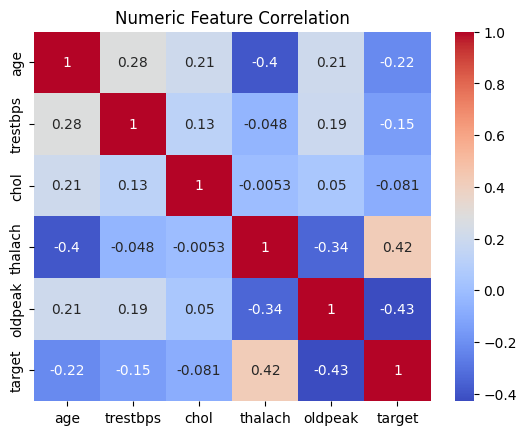

In [39]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

sns.heatmap(
    data[numeric_features + [target_col]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Numeric Feature Correlation")
plt.show()


In [40]:
pcc_scores = (
    X[numeric_features]
    .corrwith(y)
    .abs()
    .sort_values(ascending=False)
)


In [51]:
chi2_scores, _ = chi2(X[categorical_features], y)
chi2_ranking = (
    pd.Series(chi2_scores, index=categorical_features)
    .sort_values(ascending=False)
)

print(chi2_scores)

print(chi2_ranking)

[ 7.72168971 62.11608597  0.1849456   2.8777431  38.51884879  9.67771549
 74.30450299  5.7679276 ]
ca         74.304503
cp         62.116086
exang      38.518849
slope       9.677715
sex         7.721690
thal        5.767928
restecg     2.877743
fbs         0.184946
dtype: float64


In [49]:
pcc_scores = (
    X[numeric_features]
    .corrwith(y)
    .abs()
    .sort_values(ascending=False)
)

pcc_scores

oldpeak     0.429146
thalach     0.419955
age         0.221476
trestbps    0.146269
chol        0.081437
dtype: float64

In [52]:
# PCC thresholds from quantiles
pcc_quantiles = [0.6, 0.7, 0.8, 0.9]
pcc_thresholds = pcc_scores.quantile(pcc_quantiles).values

# Chi2 k from feature ratio
chi2_ratios = [0.3, 0.5, 0.7, 1.0]
chi2_k_values = [
    max(1, int(len(categorical_features) * r))
    for r in chi2_ratios
]


print("PCC thresholds:", pcc_thresholds)
print("Chi2 k values:", chi2_k_values)

PCC thresholds: [0.30086751 0.3802592  0.4217932  0.42546952]
Chi2 k values: [2, 4, 5, 8]


In [53]:
def select_features(pcc_threshold=None, chi2_k=None):
    selected = []

    if pcc_threshold is not None:
        selected += pcc_scores[pcc_scores >= pcc_threshold].index.tolist()

    if chi2_k is not None:
        selected += chi2_ranking.head(chi2_k).index.tolist()

    return list(dict.fromkeys(selected))


In [45]:
def evaluate_etcxgb(X, y, features, n_estimators):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    metrics = {"acc": [], "prec": [], "rec": [], "f1": []}
    cms = []

    for tr, ts in skf.split(X, y):
        Xtr, Xts = X.iloc[tr][features], X.iloc[ts][features]
        ytr, yts = y.iloc[tr], y.iloc[ts]

        et = ExtraTreesClassifier(
            n_estimators=n_estimators,
            random_state=42
        )
        et.fit(Xtr, ytr)

        et_tr_pred = et.predict(Xtr)
        et_ts_pred = et.predict(Xts)

        xgb_tr = np.column_stack((Xtr, et_tr_pred))
        xgb_ts = np.column_stack((Xts, et_ts_pred))

        xgb = XGBClassifier(
            n_estimators=n_estimators,
            random_state=42,
            eval_metric="logloss",
            use_label_encoder=False
        )
        xgb.fit(xgb_tr, ytr)

        y_pred = xgb.predict(xgb_ts)

        metrics["acc"].append(accuracy_score(yts, y_pred))
        metrics["prec"].append(precision_score(yts, y_pred))
        metrics["rec"].append(recall_score(yts, y_pred))
        metrics["f1"].append(f1_score(yts, y_pred))
        cms.append(confusion_matrix(yts, y_pred))

    return {
        "accuracy_mean": np.mean(metrics["acc"]),
        "accuracy_std": np.std(metrics["acc"]),
        "precision_mean": np.mean(metrics["prec"]),
        "recall_mean": np.mean(metrics["rec"]),
        "f1_mean": np.mean(metrics["f1"]),
        "confusion_matrix": np.sum(cms, axis=0)
    }


In [ ]:
results = []
n_estimators_list = [100, 200, 300]

# Baseline
for n in n_estimators_list:
    res = evaluate_etcxgb(X, y, X.columns.tolist(), n)
    results.append({
        "Scenario": "Baseline",
        "PCC_threshold": None,
        "Chi2_k": None,
        "n_estimators": n,
        "Num_features": X.shape[1],
        **res
    })

# PCC only
for t in pcc_thresholds:
    feats = select_features(pcc_threshold=t)
    for n in n_estimators_list:
        res = evaluate_etcxgb(X, y, feats, n)
        results.append({
            "Scenario": "PCC",
            "PCC_threshold": round(float(t), 3),
            "Chi2_k": None,
            "n_estimators": n,
            "Num_features": len(feats),
            **res
        })

# Chi2 only
for k in chi2_k_values:
    feats = select_features(chi2_k=k)
    for n in n_estimators_list:
        res = evaluate_etcxgb(X, y, feats, n)
        results.append({
            "Scenario": "Chi2",
            "PCC_threshold": None,
            "Chi2_k": k,
            "n_estimators": n,
            "Num_features": len(feats),
            **res
        })

# PCC + Chi2
for t in pcc_thresholds:
    for k in chi2_k_values:
        feats = select_features(t, k)
        for n in n_estimators_list:
            res = evaluate_etcxgb(X, y, feats, n)
            results.append({
                "Scenario": "PCC+Chi2",
                "PCC_threshold": round(float(t), 3),
                "Chi2_k": k,
                "n_estimators": n,
                "Num_features": len(feats),
                **res
            })

results_df = pd.DataFrame(results)


In [47]:
pivot = results_df.pivot_table(
    values="accuracy_mean",
    index="Scenario",
    columns="n_estimators"
)

friedman_stat, friedman_p = stats.friedmanchisquare(
    *[pivot[c] for c in pivot.columns]
)

nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
nemenyi.index = pivot.index
nemenyi.columns = pivot.index


ValueError: Length mismatch: Expected axis has 3 elements, new values have 4 elements